In [1]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import argparse
from pprint import pprint
import pickle as pkl
import json
import shutil
import copy

import cv2
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as scipy_R
from tqdm.auto import tqdm

import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import plotly.graph_objects as go
np.set_printoptions(suppress=True)

from preprocess import MapGraph, QueryGraph
from eva import compute_pose_error

# from preprocess.utils import (
#     GloveFeatureExtractor,
#     LAVISFeatureExtractor,
#     comp_bbox3d_edge_with_min_knn,
#     comp_bbox2d_edge_with_min_knn,
# )

from utils import (
    comp_graph_overlap,
    transform_bbox3d,
    invert_Rt,
    project_bbox3d_to_2d_xyxy,
    adjust_intrinsics_with_img_size,
)
from viz_utils import (
    viz_bbox3d_with_plotly,
    viz_bbox3d_and_cam_with_o3d,
    draw_bbox_xyxy,
)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
def read_rgb(rgb_path):
    rgb = cv2.imread(rgb_path)
    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
    return rgb

In [3]:
def read_depth(depth_path):
    depth = cv2.imread(depth_path, cv2.IMREAD_ANYDEPTH)
    depth = depth.astype(np.float32)[:,:,np.newaxis]
    # mm to m
    depth = depth / 1000
    return depth

In [4]:
def read_traj(fpath):
    df = pd.read_csv(fpath, sep=' ', header=None)
    df.columns = ['timestamp', 
                    'axis-angle-x', 'axis-angle-y', 'axis-angle-z', 
                    'tx', 'ty', 'tz']
    timestamps = df['timestamp'].apply(lambda x: f'{np.around(x, 3):.03f}')
    axis_angles = df[['axis-angle-x', 'axis-angle-y', 'axis-angle-z']].to_numpy()
    # NOTE: here is a inv to correct the orientation
    cam_R_wc = scipy_R.from_rotvec(axis_angles).inv()
    cam_t_wc = df[['tx', 'ty', 'tz']].to_numpy()
    return timestamps, cam_R_wc, cam_t_wc

In [5]:
def read_intrinsics_and_img_size(fpath):
    arr = np.loadtxt(fpath)
    w, h, fx, fy, cx, cy = arr
    img_size = (int(w), int(h))
    K = np.array([
        [fx, 0, cx],
        [0, fy, cy],
        [0, 0, 1],
    ])
    return K, img_size

In [6]:
def get_bbox3d_df(fpath):
    data_json = json.load(open(fpath, 'rb'))
    # Extracting and transforming data
    obb_src = "obbAligned"
    extracted_data = []
    for item in data_json["data"]:
        label_name = item["label"]
        centroid = item["segments"][obb_src]["centroid"]
        axes_lengths = np.array(item["segments"][obb_src]["axesLengths"])
        normalized_axes = np.array(item["segments"][obb_src]["normalizedAxes"]).reshape(3, 3)

        # Translation components
        tx, ty, tz = centroid
        # Convert rotation matrix to quaternion
        # NOTE: here is a inv to correct the orientation
        quaternion = scipy_R.from_matrix(normalized_axes).inv().as_quat()
        # Scale components
        sx, sy, sz = axes_lengths / 2

        # Append to list
        extracted_data.append([label_name, tx, ty, tz] + list(quaternion) + [sx, sy, sz])

    # Creating DataFrame
    columns = ['label_name', 'tx', 'ty', 'tz', 'qx', 'qy', 'qz', 'qw', 'sx', 'sy', 'sz']
    df = pd.DataFrame(extracted_data, columns=columns)
    return df

In [298]:
SCENE_IDX = 10
FRAME_IDX = 1135

In [299]:
ds_meta = pd.read_csv('data/ARKitScenes/3dod/metadata.csv')
ds_mask = np.logical_and(ds_meta['sky_direction'] == 'Up', ds_meta['fold'] == 'Training')
SCENE_IDS = ds_meta[ds_mask]['video_id'].values
SCENE_ID = SCENE_IDS[SCENE_IDX]
DATA_DIR = f'data/ARKitScenes/3dod/Training/{SCENE_ID}'
traj_fpath = f'{DATA_DIR}/{SCENE_ID}_frames/lowres_wide.traj'
timestamps, cam_R_wcs, cam_t_wcs = read_traj(traj_fpath)
print(SCENE_ID)

41048240


In [300]:
FRAME_ID = timestamps[FRAME_IDX]
print(FRAME_ID)
cam_R_wc, cam_t_wc = cam_R_wcs[FRAME_IDX], cam_t_wcs[FRAME_IDX]
print(cam_t_wc)
cam_R_cw, cam_t_cw = invert_Rt(cam_R_wc, cam_t_wc)
intrinsics_fpath = f'{DATA_DIR}/{SCENE_ID}_frames/lowres_wide_intrinsics/{SCENE_ID}_{FRAME_ID}.pincam'
K, img_size = read_intrinsics_and_img_size(intrinsics_fpath)

390.693
[ 3.27846  1.43974 -1.66486]


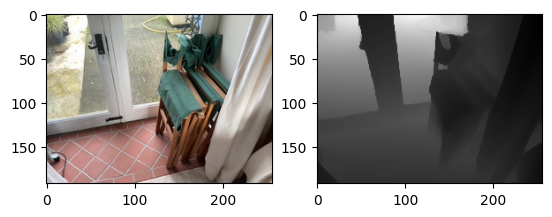

In [301]:
rgb_path = f'{DATA_DIR}/{SCENE_ID}_frames/lowres_wide/{SCENE_ID}_{FRAME_ID}.png'
depth_path = f'{DATA_DIR}/{SCENE_ID}_frames/lowres_depth/{SCENE_ID}_{FRAME_ID}.png'
rgb = read_rgb(rgb_path)
depth = read_depth(depth_path)
plt.subplot(121)
plt.imshow(rgb)
plt.subplot(122)
plt.imshow(depth, cmap='gray')

In [302]:
df = get_bbox3d_df(f'{DATA_DIR}/{SCENE_ID}_3dod_annotation.json')
bbox3d_w = df[['tx', 'ty', 'tz', 'qx', 'qy', 'qz', 'qw', 'sx', 'sy', 'sz']].values
df

,label_name,tx,ty,tz,qx,qy,qz,qw,sx,sy,sz
0,sofa,0.269073,1.750394,-1.206456,-0.000000,-0.000000,-0.122550,0.992462,0.500593,0.983329,0.353687
1,sofa,2.846649,0.465219,-1.138188,-0.000000,-0.000000,-0.961868,-0.273514,0.492336,0.995423,0.421955
2,cabinet,3.388600,-0.678671,-0.151827,0.000186,-0.000445,-0.992867,-0.119229,0.291136,0.285440,0.409767
3,table,3.777588,2.375020,-1.223918,-0.000000,-0.000000,-0.783882,0.620909,0.227821,0.302607,0.361450
4,fireplace,2.185193,2.814669,-1.042559,-0.000000,-0.000000,-0.783882,0.620909,0.269035,0.470423,0.542810
5,table,0.418931,3.232445,-1.238264,0.001186,-0.001056,-0.541824,0.840491,0.151422,0.245484,0.151835
6,tv_monitor,0.368277,3.091898,-0.498397,0.056307,0.093474,-0.530528,0.840614,0.013548,0.375903,0.224116
7,chair,4.345700,1.242969,-1.131597,-0.000000,-0.000000,-0.993958,-0.109764,0.296329,0.123554,0.453771
8,chair,4.302681,1.050564,-1.162736,-0.000000,-0.000000,-0.993958,-0.109764,0.296329,0.073520,0.422632
9,chair,4.270581,0.907001,-1.163768,-0.000000,-0.000000,-0.993958,-0.109764,0.296329,0.073762,0.421601


In [303]:
fig = viz_bbox3d_with_plotly(bbox3d_w, df['label_name'])
fig.add_trace(go.Scatter3d(x=[cam_t_wc[0]],
                           y=[cam_t_wc[1]],
                           z=[cam_t_wc[2]],
                           mode='markers',
                           name='camera'))
fig.show()

In [304]:
# cam_pose = np.concatenate([cam_t_wc, cam_R_wc.as_quat()])
# viz_bbox3d_and_cam_with_o3d(bbox3d_w, cam_pose)

In [305]:
bbox3d_c = transform_bbox3d(bbox3d_w, cam_R_cw, cam_t_cw)
bbox_proj_xyxy = project_bbox3d_to_2d_xyxy(bbox3d_c, K)
bbox_proj_xyxy[:, [0, 2]] = np.clip(bbox_proj_xyxy[:, [0, 2]], 0, img_size[0])
bbox_proj_xyxy[:, [1, 3]] = np.clip(bbox_proj_xyxy[:, [1, 3]], 0, img_size[1])

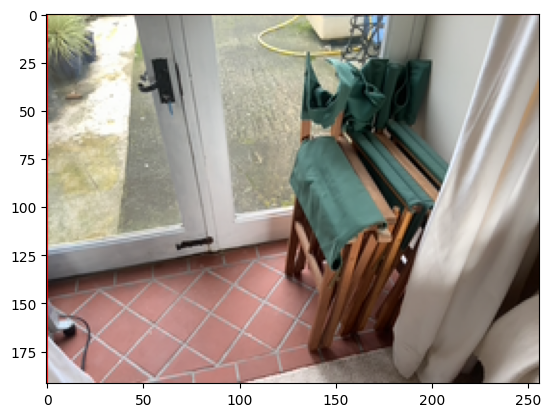

In [306]:
img = copy.deepcopy(rgb)
for bbox in bbox_proj_xyxy:
    draw_bbox_xyxy(img, bbox, thickness=1, color=(255, 0, 0))
plt.imshow(img)